In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score,roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.compose import make_column_transformer
import plotly.express as px
import tensorflow as tf

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


*# This is my fourth competiton! The results tell me that I have to improve and do much more better than before #*

# 1. Load Dataset

In [2]:
train_dataset = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test_dataset = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")

# 2. EDA

In [3]:
train_dataset.head(5)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
train_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


### Outliers
When I checked the 25% and 75% parts in each variable, I saw some variables they have outliers like:
* Annual_Income_USD
* Daily_Commute_km
* Charging_Stations_Near_Home
* Charging_Stations_Near_Work 

In [5]:
train_dataset.isnull().sum(),test_dataset.isnull().sum()

(id                             0
 Age                            0
 Annual_Income_USD              0
 Daily_Commute_km               0
 Number_of_Cars_Owned           0
 Charging_Stations_Near_Home    0
 Charging_Stations_Near_Work    0
 Environmental_Concern_Level    0
 Gender                         0
 City_Type                      0
 Current_Car_Type               0
 Home_Charging_Possible         0
 Subsidy_Available              0
 Range_Anxiety_Level            0
 Will_Buy_EV                    0
 dtype: int64,
 id                             0
 Age                            0
 Annual_Income_USD              0
 Daily_Commute_km               0
 Number_of_Cars_Owned           0
 Charging_Stations_Near_Home    0
 Charging_Stations_Near_Work    0
 Environmental_Concern_Level    0
 Gender                         0
 City_Type                      0
 Current_Car_Type               0
 Home_Charging_Possible         0
 Subsidy_Available              0
 Range_Anxiety_Level            0

### Null and NA Values
- There is no null value in the train and test dataset...

In [6]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [7]:
train_dataset["Daily_commute_car"] = train_dataset["Daily_Commute_km"]/train_dataset["Number_of_Cars_Owned"]
train_dataset["Daily_commute_car"]

0         11.70
1          5.00
2         36.80
3         11.85
4         50.80
          ...  
668660    13.70
668661     2.50
668662    24.20
668663    21.85
668664     5.00
Name: Daily_commute_car, Length: 668665, dtype: float64

In [8]:
test_dataset["Daily_commute_car"] = test_dataset["Daily_Commute_km"]/test_dataset["Number_of_Cars_Owned"]

In [9]:
numeric_variables = train_dataset.select_dtypes(exclude = "object").columns.to_list()
numeric_variables.remove("id")

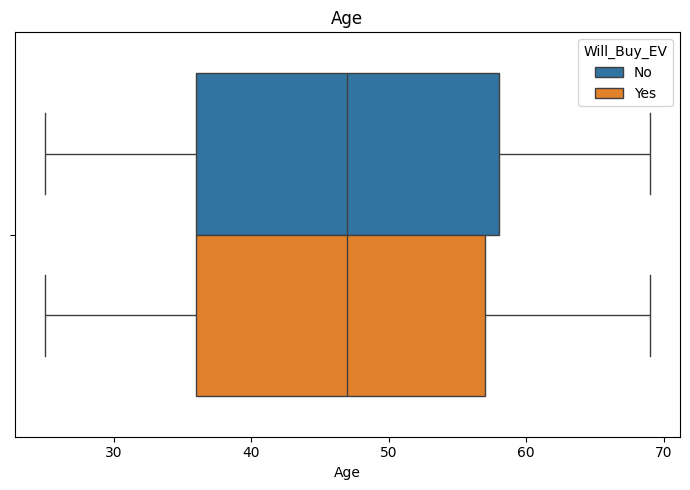

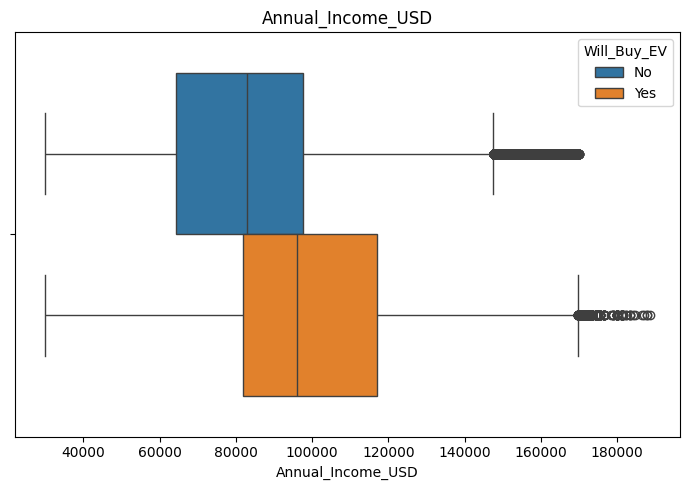

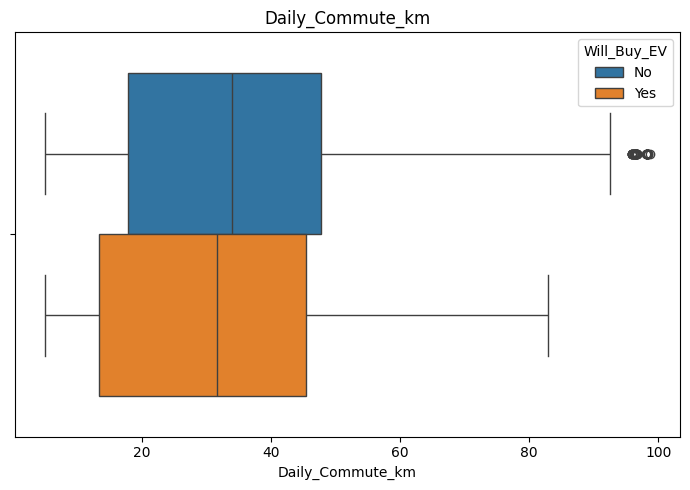

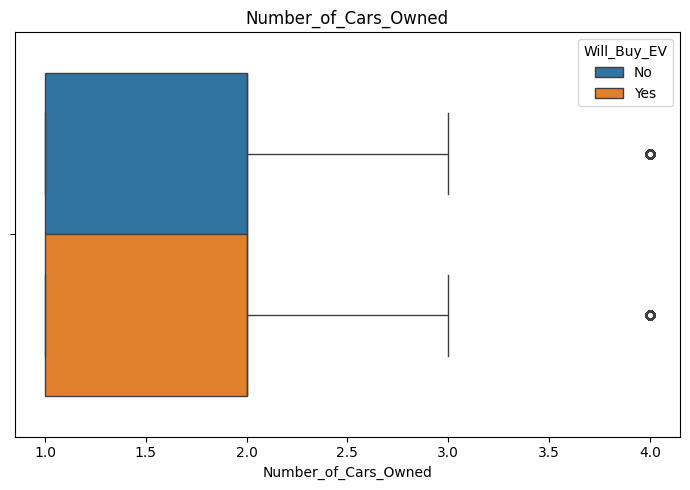

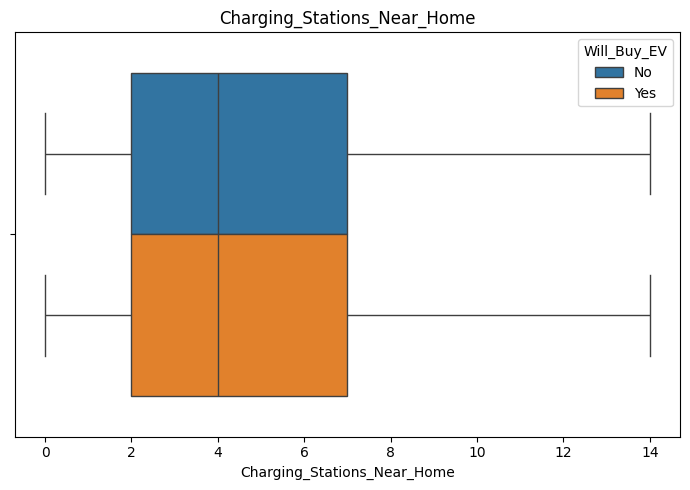

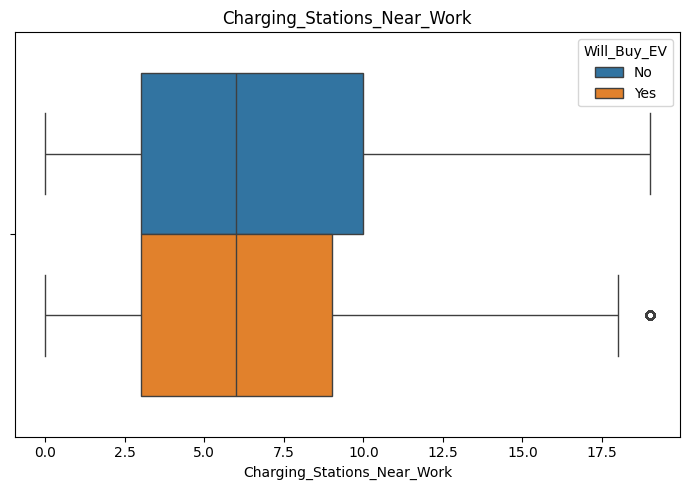

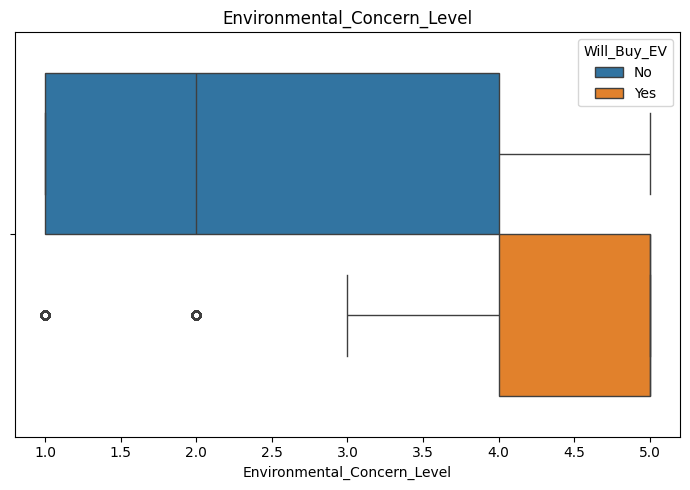

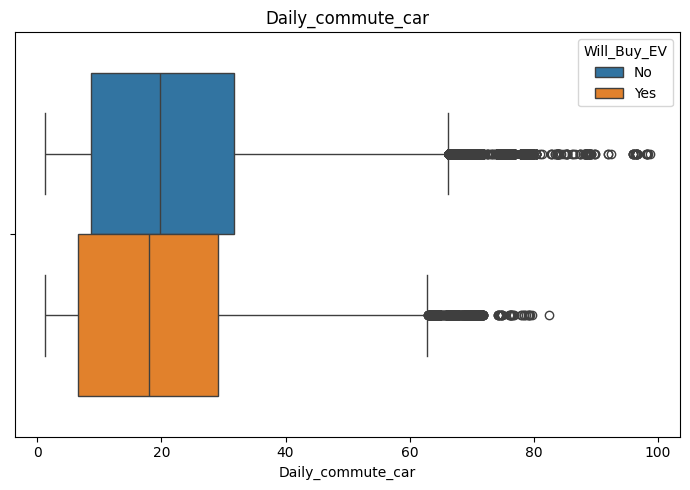

In [10]:
for numeric in numeric_variables:
    plt.figure(figsize=(7,5))
    sns.boxplot(data = train_dataset,x=numeric,hue = "Will_Buy_EV")
    plt.title(numeric)
    plt.tight_layout()

### Categorical Analysis

In [11]:
category = train_dataset.select_dtypes(include= "object").columns.to_list()
category

['Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level',
 'Will_Buy_EV']

In [12]:
train_dataset[category].head(10)

,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,Male,Suburban,Sedan,Yes,No,Low,No
1,Male,Rural,SUV,Yes,No,Low,No
2,Female,Urban,Sedan,No,Yes,Low,Yes
3,Male,Suburban,Hatchback,Yes,No,Low,No
4,Male,Suburban,Hatchback,Yes,No,Low,No
5,Other,Urban,Sedan,No,No,Low,No
6,Male,Suburban,Sedan,Yes,Yes,Low,Yes
7,Other,Urban,SUV,No,Yes,Medium,No
8,Female,Urban,Sedan,No,Yes,Medium,No
9,Male,Rural,Sedan,Yes,Yes,Low,Yes


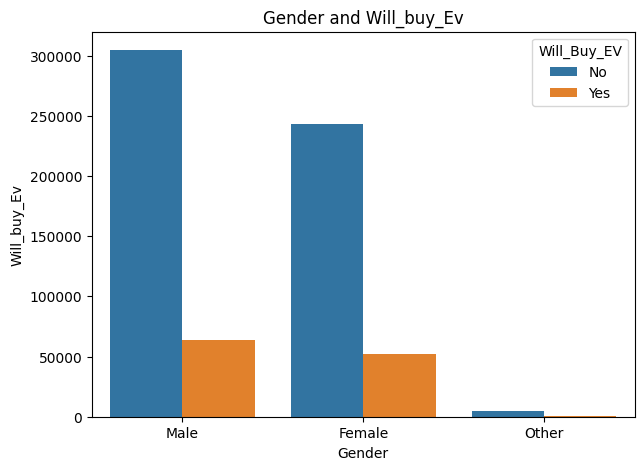

In [13]:
plt.figure(figsize = (7,5))
sns.countplot(data = train_dataset,x = "Gender",hue = "Will_Buy_EV")
plt.title("Gender and Will_buy_Ev")
plt.xlabel("Gender")
plt.ylabel("Will_buy_Ev")
plt.show()

In [14]:
train_dataset["Current_Car_Type"].value_counts()

Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

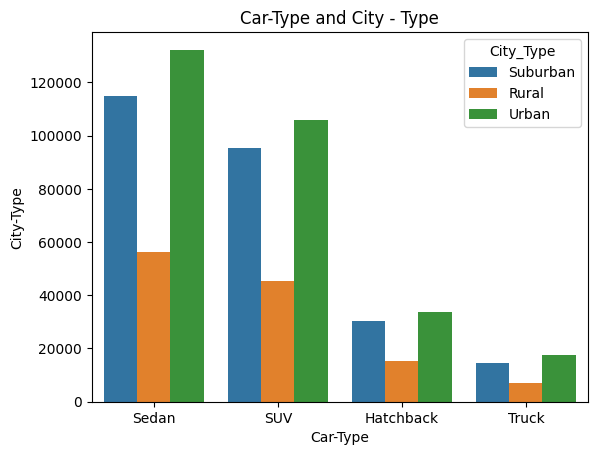

In [15]:
sns.countplot(data = train_dataset,x = "Current_Car_Type",hue= "City_Type")
plt.title("Car-Type and City - Type")
plt.xlabel("Car-Type")
plt.ylabel("City-Type")
plt.show()

### Removing Outliers

In [16]:
outlier_mask = pd.Series(False,index= train_dataset.index)
for numeric in numeric_variables:
    Q1 = train_dataset[numeric].quantile(0.25)
    Q3 = train_dataset[numeric].quantile(0.75)
    IQR = Q3-Q1
    upper_border = Q3 + 1.5*IQR
    lower_border = Q1 - 1.5*IQR
    column_mask = ((train_dataset[numeric]<lower_border)|(train_dataset[numeric]>upper_border))
    outlier_mask = outlier_mask | column_mask
    print(column_mask.sum())
    if column_mask.any():
        print(train_dataset.loc[column_mask,numeric])
print(train_dataset.loc[outlier_mask])

0
3678
151       155959.0
324       172334.0
349       163069.0
915       159832.0
917       163082.0
            ...   
667646    157619.0
668162    165514.0
668178    159939.0
668245    162973.0
668654    169626.0
Name: Annual_Income_USD, Length: 3678, dtype: float64
41
3893      98.2
45940     96.3
72110     96.5
76175     96.7
118148    96.4
185435    96.6
205755    98.2
211325    98.2
220534    98.7
229038    96.4
249432    98.3
278180    98.2
297645    96.6
343429    96.0
352719    96.6
353235    96.7
356995    96.0
358792    96.0
380417    96.7
388339    98.3
392429    96.6
392858    96.6
409476    96.3
422897    98.3
432054    98.4
487805    96.3
487917    96.4
500118    98.1
526459    98.2
538604    98.2
556117    96.0
556773    98.3
560791    96.2
574676    96.3
604928    98.3
605858    96.6
606725    98.2
616441    96.0
623821    96.0
625452    98.4
653352    96.6
Name: Daily_Commute_km, dtype: float64
13489
18        4
21        4
39        4
56        4
227       4
       

In [17]:
train_dataset_ = train_dataset.loc[~outlier_mask].copy()
train_dataset_

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Daily_commute_car
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No,11.70
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No,5.00
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes,36.80
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,11.85
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,50.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No,13.70
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No,2.50
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No,24.20
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No,21.85


In [18]:
def outlier_with_boxplot(data,n_variables):
    for n in n_variables:
        plt.figure(figsize = (7,5))
        sns.boxplot(data = data,x = n)
        plt.title(n)
        plt.show()

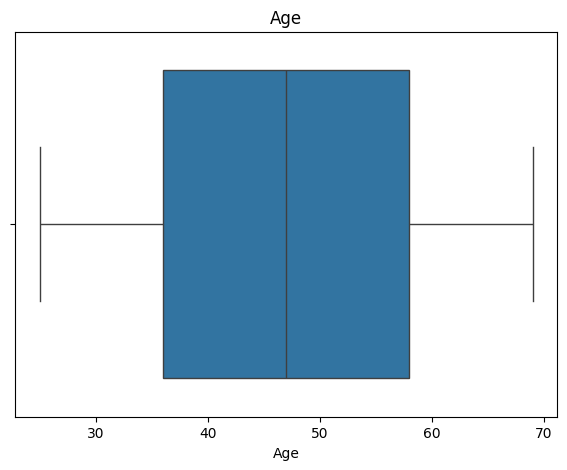

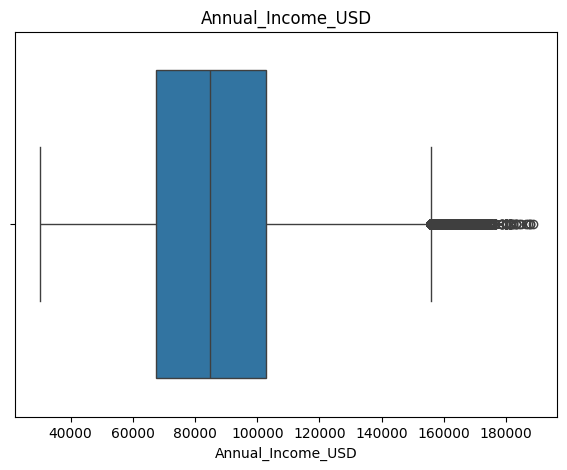

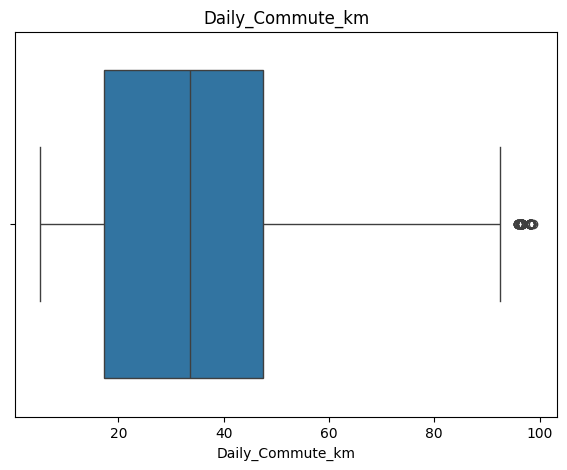

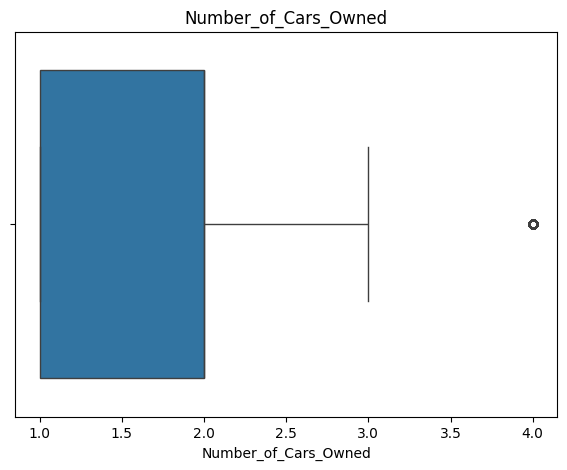

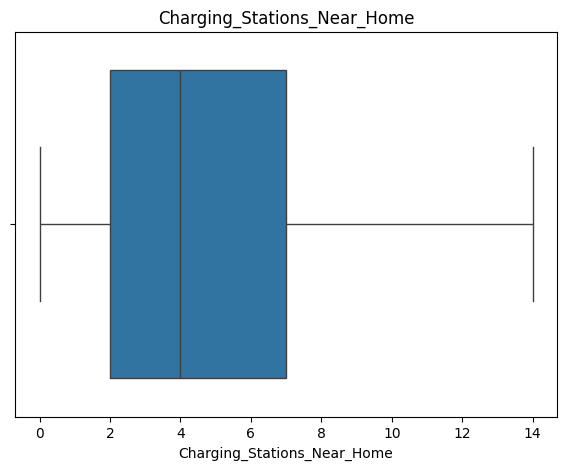

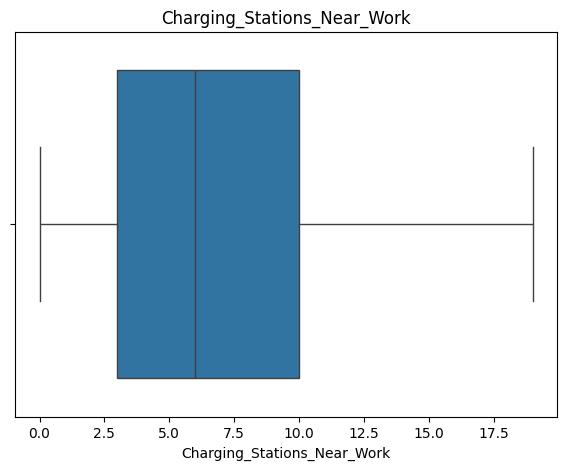

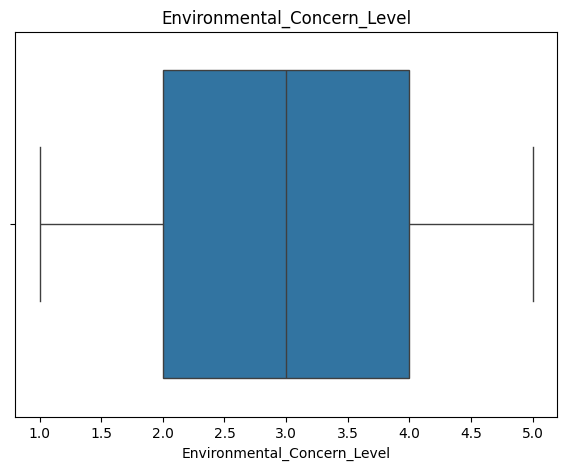

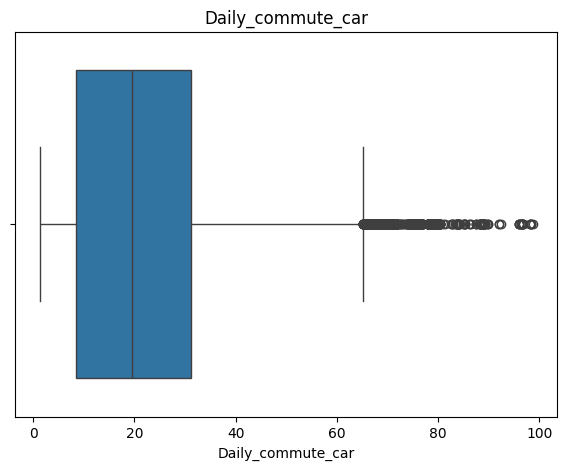

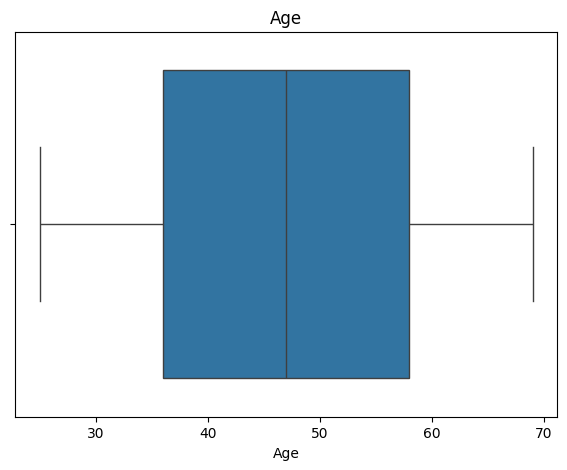

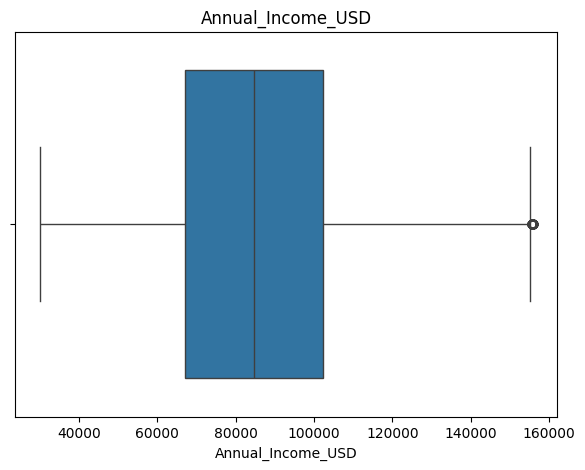

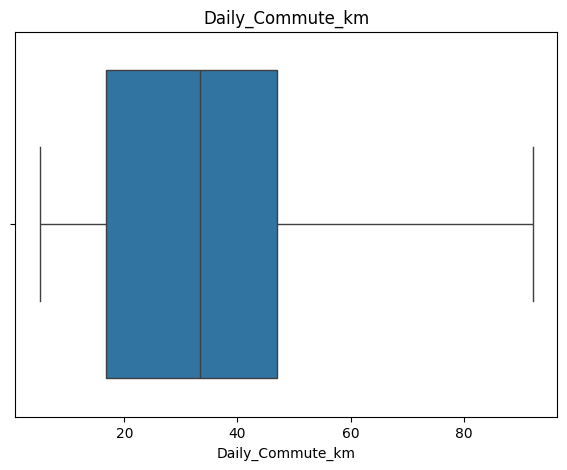

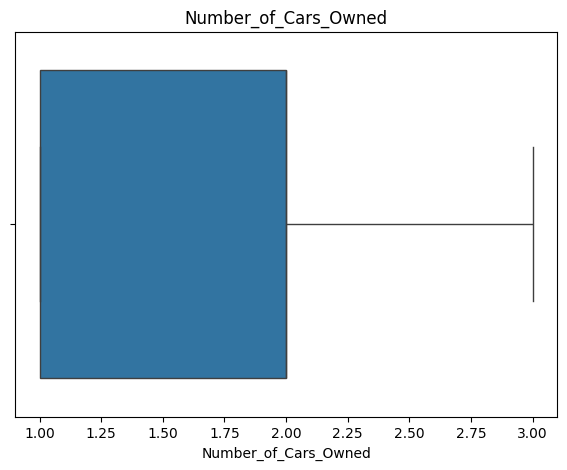

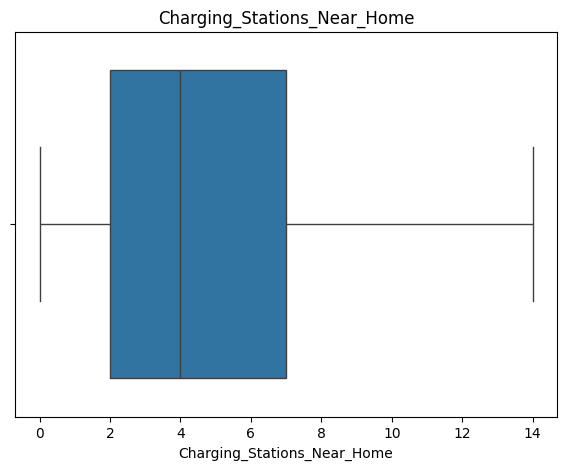

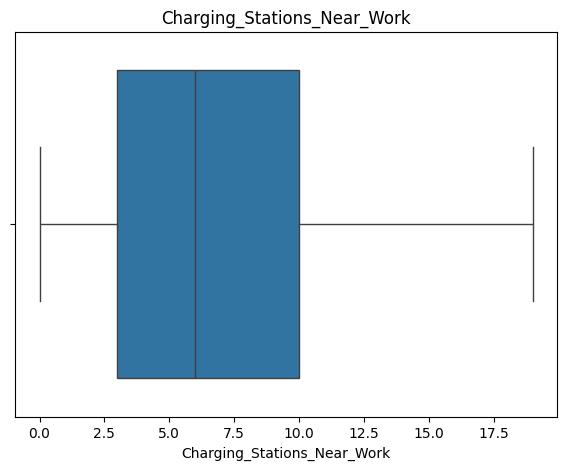

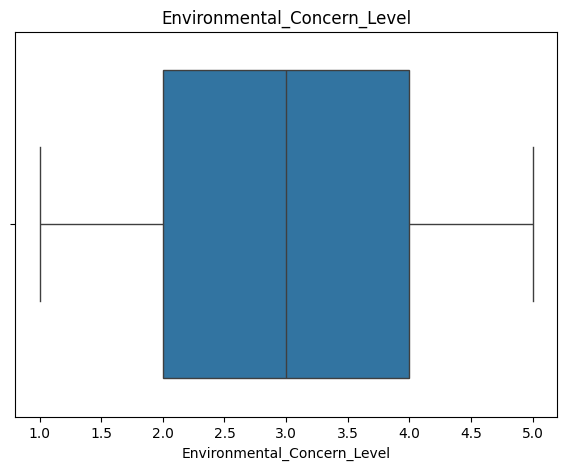

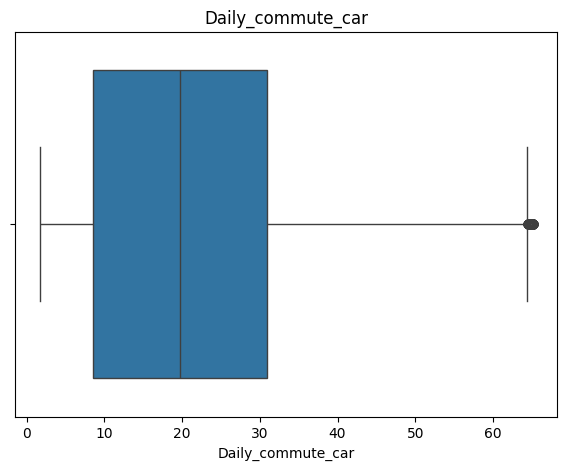

(None, None)

In [19]:
outlier_with_boxplot(train_dataset,numeric_variables),outlier_with_boxplot(train_dataset_,numeric_variables)

### Convert the datatype of the target to the int

In [20]:
train_dataset_.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV',
       'Daily_commute_car'],
      dtype='object')

In [21]:
train_dataset_["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     532326
Yes    112546
Name: count, dtype: int64

In [22]:
yes_no_map = {"No":0,"Yes":1}
train_dataset_["Will_Buy_EV"] = train_dataset_["Will_Buy_EV"].map(yes_no_map)
train_dataset_["Will_Buy_EV"].value_counts()
train_dataset_["Will_Buy_EV"] = train_dataset_["Will_Buy_EV"].astype("int32")

In [23]:
category.remove("Will_Buy_EV")

# 3. Prepare the data to the modeling

In [24]:
train_dataset_.dtypes

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                      int32
Daily_commute_car              float64
dtype: object

In [25]:
num_col = train_dataset_.select_dtypes(exclude = "object").columns.to_list()
cat_col = train_dataset_.select_dtypes(include = "object").columns.to_list()
num_col.remove("Will_Buy_EV")

In [26]:
num_col.remove("id")

In [27]:
X = train_dataset_.drop(columns = ["Will_Buy_EV","id"])
y = train_dataset_["Will_Buy_EV"]
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 42,test_size = 0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((515897, 14), (128975, 14), (515897,), (128975,))

In [28]:
mct = make_column_transformer((OneHotEncoder(handle_unknown = "ignore",dtype = "int64"),cat_col),
                             (MinMaxScaler(),num_col))
X_train_scaled = mct.fit_transform(X_train)
X_test_scaled = mct.transform(X_test)
X_train_scaled,X_test_scaled

(array([[0.        , 1.        , 0.        , ..., 0.10526316, 0.75      ,
         0.05254861],
        [1.        , 0.        , 0.        , ..., 0.89473684, 0.25      ,
         0.56016816],
        [0.        , 1.        , 0.        , ..., 0.73684211, 0.        ,
         0.339464  ],
        ...,
        [0.        , 1.        , 0.        , ..., 0.10526316, 0.        ,
         0.75880189],
        [1.        , 0.        , 0.        , ..., 0.89473684, 0.75      ,
         0.14083027],
        [0.        , 1.        , 0.        , ..., 0.47368421, 1.        ,
         0.58381503]]),
 array([[1.        , 0.        , 0.        , ..., 0.31578947, 0.75      ,
         0.21650026],
        [0.        , 1.        , 0.        , ..., 0.10526316, 0.        ,
         0.48922754],
        [0.        , 1.        , 0.        , ..., 0.57894737, 1.        ,
         0.62165003],
        ...,
        [0.        , 1.        , 0.        , ..., 0.36842105, 0.25      ,
         0.57277982],
        [1. 

In [29]:
test_dataset_ = test_dataset.drop(columns = "id").copy()
test_dataset_scaled = mct.transform(test_dataset_)
test_dataset_scaled

array([[0.        , 1.        , 0.        , ..., 0.21052632, 0.75      ,
        0.10693642],
       [0.        , 1.        , 0.        , ..., 0.47368421, 0.75      ,
        0.30399369],
       [1.        , 0.        , 0.        , ..., 0.57894737, 0.75      ,
        0.81397793],
       ...,
       [1.        , 0.        , 0.        , ..., 0.36842105, 0.75      ,
        0.19758276],
       [1.        , 0.        , 0.        , ..., 0.36842105, 0.        ,
        0.01313715],
       [1.        , 0.        , 0.        , ..., 0.36842105, 0.        ,
        0.05254861]])

# 4. Model

In [30]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500,activation = "relu"),
    tf.keras.layers.Dense(250,activation = "relu"),
    tf.keras.layers.Dense(100,activation = "relu"),
    tf.keras.layers.Dense(10,activation = "relu"),
    tf.keras.layers.Dense(1,activation = "sigmoid")
])

model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
             optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
             metrics = ["accuracy"])

early_stop = tf.keras.callbacks.EarlyStopping(monitor = "val_loss",
                                             patience = 5,
                                         restore_best_weights = True)

history = model.fit(X_train_scaled,y_train,epochs = 20,callbacks = early_stop,validation_data = (X_test_scaled,y_test),
                   batch_size = 32)

Epoch 1/20


2026-09-22 18:31:25.588715: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16122/16122 ━━━━━━━━━━━━━━━━━━━━ 78s 5ms/step - accuracy: 0.8898 - loss: 0.2440 - val_accuracy: 0.8939 - val_loss: 0.2425
Epoch 2/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - accuracy: 0.8919 - loss: 0.2394 - val_accuracy: 0.8935 - val_loss: 0.2431
Epoch 3/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.8918 - loss: 0.2394 - val_accuracy: 0.8901 - val_loss: 0.2513
Epoch 4/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - accuracy: 0.8912 - loss: 0.2405 - val_accuracy: 0.8938 - val_loss: 0.2367
Epoch 5/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - accuracy: 0.8927 - loss: 0.2378 - val_accuracy: 0.8941 - val_loss: 0.2377
Epoch 6/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - accuracy: 0.8921 - loss: 0.2393 - val_accuracy: 0.8934 - val_loss: 0.2408
Epoch 7/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 0.8928 - loss: 0.2381 - val_accuracy: 0.8917 - val_loss: 0.2390
Epoch 8/20
16122/16122 ━━━━━━━━━━━━━━━━━━━━ 79s 5ms/step - accuracy: 0.8930 - lo

<Axes: title={'center': 'Model Performance'}>

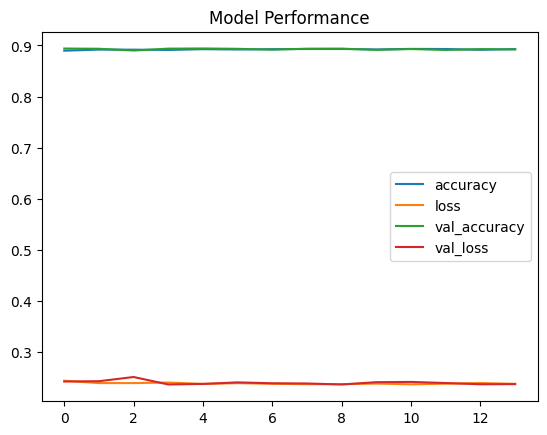

In [31]:
pd.DataFrame(history.history).plot(title = "Model Performance")

In [32]:
preds = model.predict(test_dataset_scaled)
preds

8956/8956 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


array([[9.2975087e-03],
       [5.1864453e-02],
       [6.6205095e-03],
       ...,
       [4.3609887e-03],
       [1.7509726e-04],
       [9.8641962e-05]], dtype=float32)

In [33]:
pred = (preds>0.5).astype("int")
pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [34]:
submission = pd.DataFrame({"id":test_dataset["id"],"Will_Buy_EV":pred.squeeze()})
submission["Will_Buy_EV"].value_counts()

Will_Buy_EV
0    238547
1     48024
Name: count, dtype: int64

In [35]:
submission.to_csv("submission-4.csv",index = False)

In [36]:
num_zero = (y_train == 0).sum()
num_one = (y_train  == 1).sum()
num_zero,num_one
ratio = num_zero/num_one
ratio

np.float64(4.743036847378382)

In [37]:
lgc = LGBMClassifier(
    max_depth = 8,
    n_estimators = 1500,
    learning_rate = 0.06,
    scale_pos_weight  = 2.16,
    metric = "auc",
    num_leaves = 31
)
lgc.fit(X_train_scaled,y_train)

lgc_preds = lgc.predict(X_test_scaled)

[LightGBM] [Info] Number of positive: 89830, number of negative: 426067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 887
[LightGBM] [Info] Number of data points in the train set: 515897, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174124 -> initscore=-1.556678
[LightGBM] [Info] Start training from score -1.556678


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [38]:
lgc_preds

array([1, 0, 0, ..., 0, 0, 0], dtype=int32)

In [39]:
accuracy = accuracy_score(y_test,lgc_preds)
accuracy*100

88.42798992052724

In [40]:
f1 = f1_score(y_test,lgc_preds)
f1

0.7129862887252169

In [41]:
from sklearn.metrics import classification_report
cp = classification_report(y_test,lgc_preds)
print(cp)

              precision    recall  f1-score   support

           0       0.96      0.90      0.93    106259
           1       0.63      0.82      0.71     22716

    accuracy                           0.88    128975
   macro avg       0.80      0.86      0.82    128975
weighted avg       0.90      0.88      0.89    128975



In [42]:
sub_pred = lgc.predict(test_dataset_scaled)
submission = pd.DataFrame({"id":test_dataset["id"],"Will_Buy_EV":sub_pred})
submission.to_csv("Submission-6.csv",index = False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
cat = CatBoostClassifier(iterations = 1500,
                        learning_rate = 0.05,
                        max_depth = 8,
                         auto_class_weights = "SqrtBalanced",
                         l2_leaf_reg = 6,
                        eval_metric = "AUC",
                        random_state = 42)


In [44]:
cat.fit(X_train_scaled,y_train,verbose = 100)
y_pred = cat.predict(X_test_scaled)
cp = classification_report(y_test,y_pred)
print(cp)

0:	total: 154ms	remaining: 3m 50s
100:	total: 8.02s	remaining: 1m 51s
200:	total: 15.6s	remaining: 1m 40s
300:	total: 23.3s	remaining: 1m 32s
400:	total: 31.1s	remaining: 1m 25s
500:	total: 39.5s	remaining: 1m 18s
600:	total: 47.3s	remaining: 1m 10s
700:	total: 55.2s	remaining: 1m 2s
800:	total: 1m 3s	remaining: 55.4s
900:	total: 1m 11s	remaining: 47.7s
1000:	total: 1m 19s	remaining: 39.7s
1100:	total: 1m 27s	remaining: 31.8s
1200:	total: 1m 36s	remaining: 24s
1300:	total: 1m 46s	remaining: 16.4s
1400:	total: 1m 56s	remaining: 8.21s
1499:	total: 2m 4s	remaining: 0us
              precision    recall  f1-score   support

           0       0.96      0.90      0.93    106259
           1       0.63      0.82      0.71     22716

    accuracy                           0.88    128975
   macro avg       0.79      0.86      0.82    128975
weighted avg       0.90      0.88      0.89    128975



In [45]:
preds = cat.predict(test_dataset_scaled)
cat_sub = pd.DataFrame({"id":test_dataset["id"],
                       "Will_Buy_EV":preds})
cat_sub.to_csv("Submission-7.csv",index = False)